In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [3]:
print(f"Train shape : {train.shape}")
print(f"Test shape : {test.shape}")

Train shape : (891, 12)
Test shape : (418, 11)


In [4]:
test_passenger_ids = test["PassengerId"]

In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

**Analysis of Numerical Features**

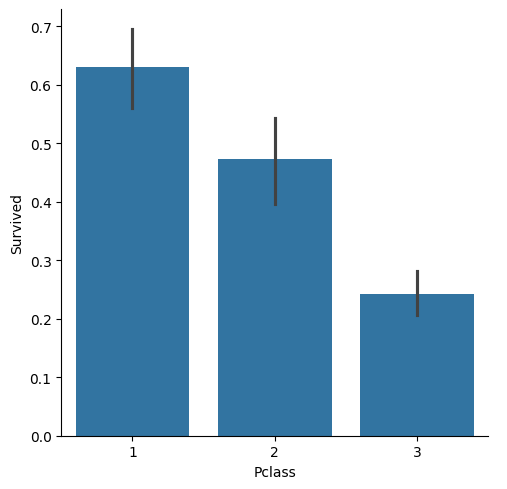

In [9]:
import seaborn as sns

g = sns.catplot(data=train,x="Pclass",y="Survived",kind="bar")
# Survival chances are in order of Pclass 1>2>3

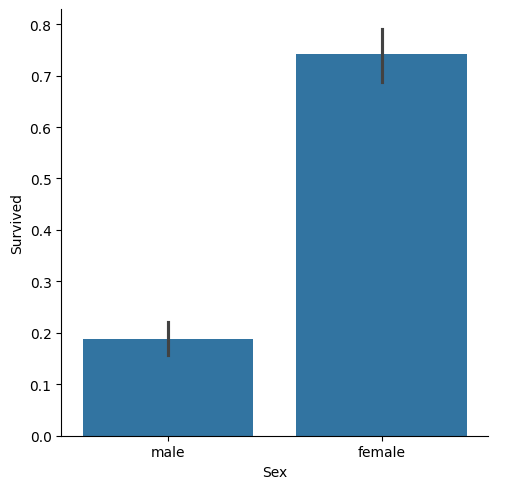

In [10]:
g = sns.catplot(data=train,x="Sex",y="Survived",kind="bar")
# Females have significantly higher chances of survival

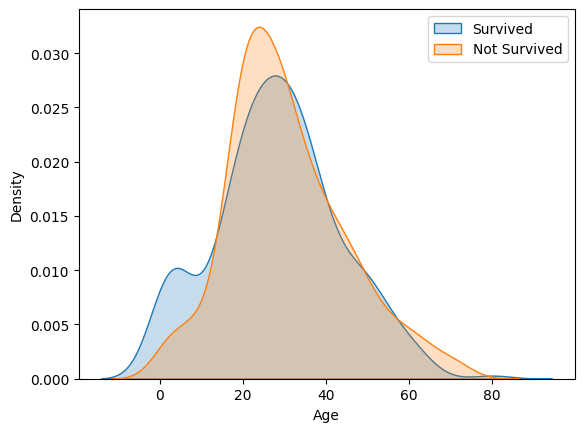

In [11]:
g = sns.kdeplot(data=train[train["Survived"]==1]["Age"],fill=True)
g = sns.kdeplot(data=train[train["Survived"]==0]["Age"],fill=True)
g = g.legend(["Survived","Not Survived"])
# Very low ages have higher survival chances

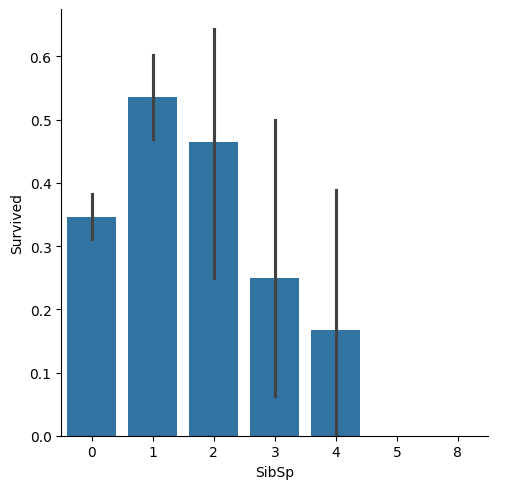

In [12]:
sns.catplot(data=train,x="SibSp",y="Survived",kind="bar")
# Higher SibSp have lower survival chances

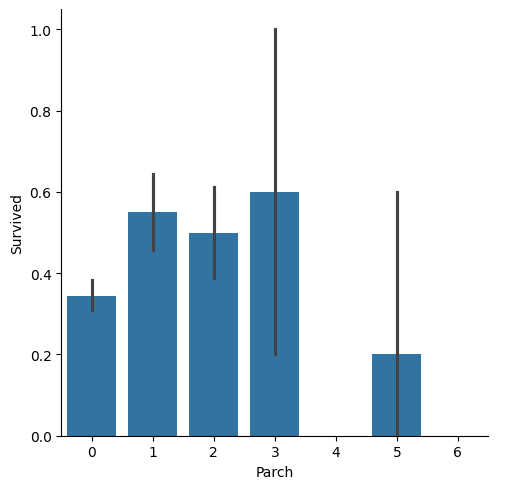

In [13]:
sns.catplot(data=train,x="Parch",y="Survived",kind="bar")
# Not a very good measure but higher Parch somewhat lower chances

In [14]:
len(train[train["Parch"]==4])
# So all 4 of these did not survive and it is not the case that there is no passenger with 4 Parch

4

<Axes: xlabel='Fare', ylabel='Density'>

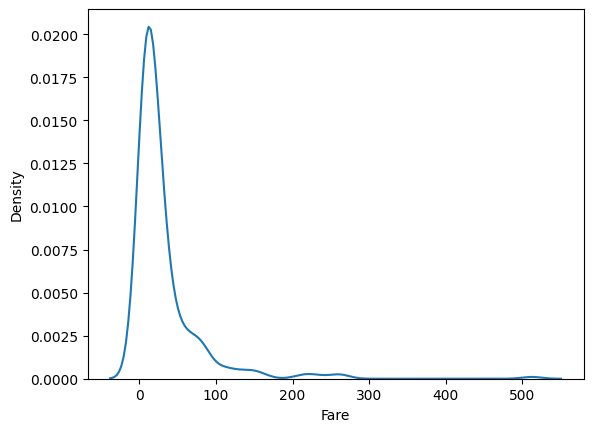

In [15]:
sns.kdeplot(data=train,x="Fare")
# Fare amounts have a long tail, skewed distribution

<Axes: xlabel='Fare', ylabel='Density'>

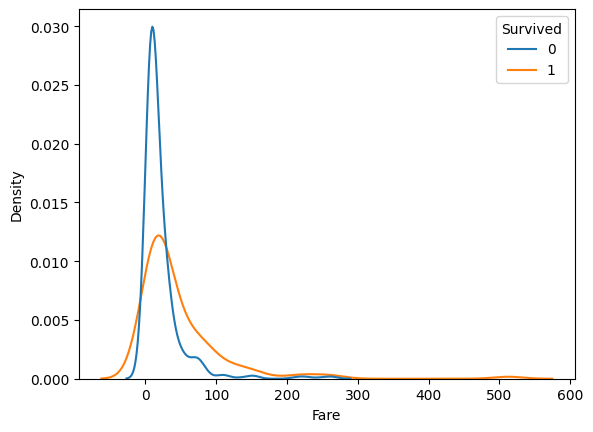

In [16]:
sns.kdeplot(data=train,x="Fare",hue="Survived",common_norm=False)

<Axes: xlabel='Survived', ylabel='Fare'>

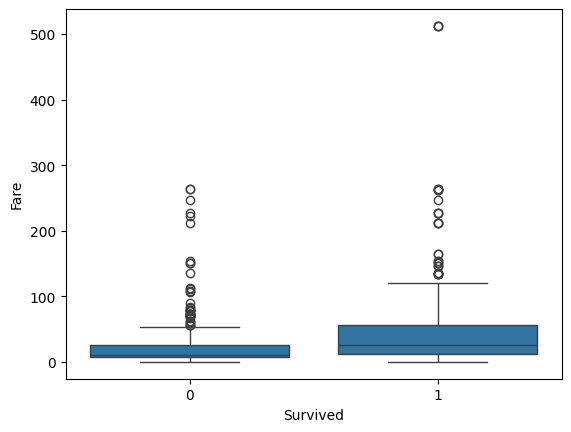

In [17]:
sns.boxplot(data=train,x="Survived",y="Fare")
# Removing outliers doesnt seem to be a good idea since some very high paying passengers tend to have survive

<Axes: xlabel='Survived', ylabel='Fare'>

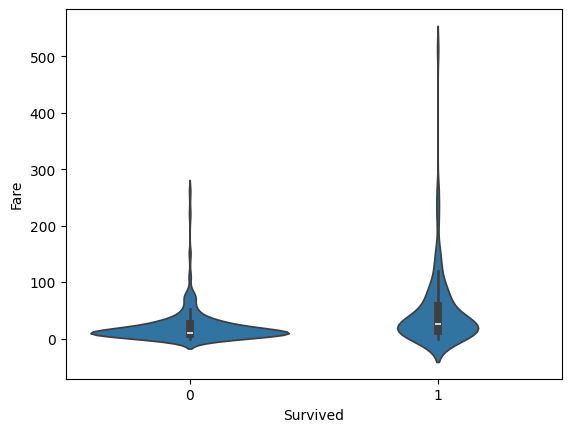

In [18]:
sns.violinplot(data=train,x="Survived",y="Fare")
# Takeaway is that higher fare paying passengers had better survival chances

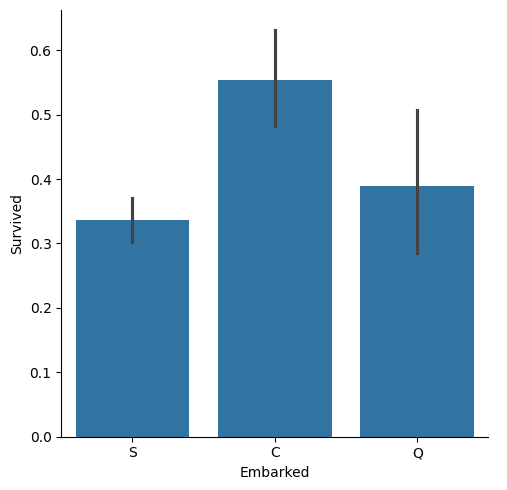

In [19]:
sns.catplot(data=train,x="Embarked",y="Survived",kind="bar")

In [20]:
train["Sex"] = train["Sex"].apply(lambda p: 1 if p=="male" else 0)
test["Sex"] = test["Sex"].apply(lambda p: 1 if p=="male" else 0)

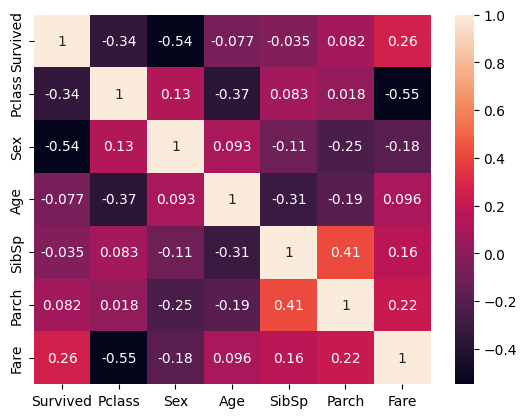

In [21]:
g = sns.heatmap(train[["Survived","Pclass","Sex","Age","SibSp","Parch","Fare"]].corr(),annot=True)
# Sex and Pclass are very well correlateed
# Fare is also a good indicator
# Age,Parch,SibSp do not have high correlation - but from previous bar plots : Very low ages,low SibSp have fairly better chances 

**Analysing and Improving correlation of low correlated features**

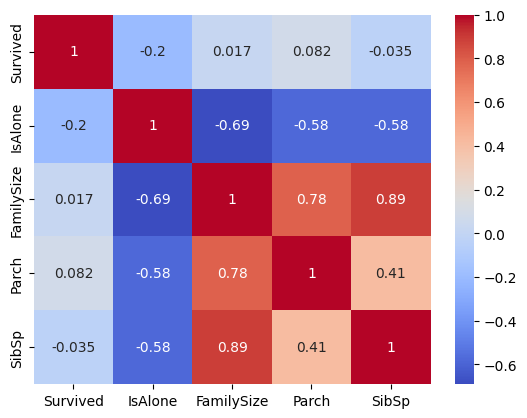

In [22]:
# To improve the impact of Parch and SibSp data, new "FamilySize" variable might prove to be helpful
train["FamilySize"] = 1+train["SibSp"]+train["Parch"]
train["IsAlone"] = (train["FamilySize"]==1).astype(int)
g = sns.heatmap(train[["Survived","IsAlone","FamilySize","Parch","SibSp"]].corr(),annot=True,cmap="coolwarm")
# IsAlone is an excellent feature but considering dropping Parch,SibSp,FamilySize
# Parch SibSp and FamilySize are multicollinear so tryining dropping Parch and SibSp

,Survived,Family_Solo,Family_Small,Family_Large
Survived,1.000000,-0.203367,0.279855,-0.125147
Family_Solo,-0.203367,1.000000,-0.859931,-0.336825
Family_Small,0.279855,-0.859931,1.000000,-0.190940
Family_Large,-0.125147,-0.336825,-0.190940,1.000000


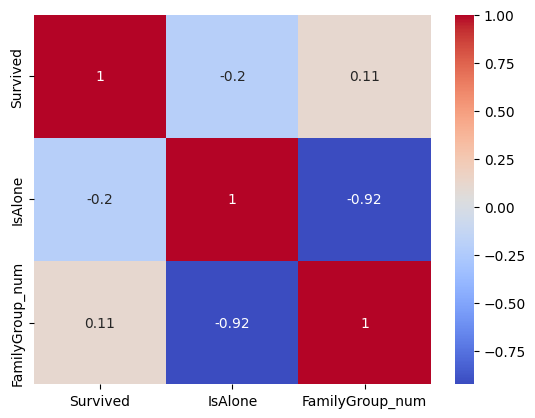

In [23]:
# Experimenting on copy of trianing dataset
train2 = train.copy()
train2['FamilyGroup'] = pd.cut(train2['FamilySize'],bins=[0,1,4,11],labels=['Solo','Small','Large'])

train2 = train2.drop(columns=['SibSp','Parch','FamilySize'])
group_mapping = {'Solo': 0, 'Small': 1, 'Large': 2}
train2['FamilyGroup_num'] = train2['FamilyGroup'].map(group_mapping)
g = sns.heatmap(train2[["Survived","IsAlone","FamilyGroup_num"]].corr(),annot=True,cmap="coolwarm")

family_dummies = pd.get_dummies(train2['FamilyGroup'],prefix='Family')
pd.concat([train2[["Survived"]],family_dummies],axis=1).corr()
# These Experiments are suggestive that One-Hot Family Size Groupings are better correlated than individual SibSp and Parch
# although raw correlation matrix of FamilySize suggested otherwise since this is a non linear relationship
# Also IsAlone and FamilyGroup have high correlation since IsAlone is just FamilyGroup_Solo, so can safely drop IsAlone

In [24]:
train["FamilyGroup"] = pd.cut(train["FamilySize"],bins=[0,1,4,11],labels=["Solo","Small","Large"])
train = train.drop(columns=["SibSp","Parch","FamilySize"],axis=1)
train_family_dummies = pd.get_dummies(train["FamilyGroup"],prefix="Family",dtype=int)
train = pd.concat([train,train_family_dummies],axis=1)

test["FamilySize"] = test["Parch"]+test["SibSp"]+1

test["FamilyGroup"] = pd.cut(test["FamilySize"],bins=[0,1,4,11],labels=["Solo","Small","Large"])
test = test.drop(columns=["SibSp","Parch","FamilySize"],axis=1)
test_family_dummies = pd.get_dummies(test["FamilyGroup"],prefix="Family",dtype=int)
test = pd.concat([test,test_family_dummies],axis=1)


In [25]:
train = train.drop(columns=["IsAlone"],axis=1)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,FamilyGroup,Family_Solo,Family_Small,Family_Large
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,A/5 21171,7.2500,NaN,S,Small,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,PC 17599,71.2833,C85,C,Small,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,STON/O2. 3101282,7.9250,NaN,S,Solo,1,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,113803,53.1000,C123,S,Small,0,1,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,373450,8.0500,NaN,S,Solo,1,0,0


In [26]:
train = train.drop(columns=["FamilyGroup"])
test = test.drop(columns=["FamilyGroup"])

In [27]:
train["Embarked"] = train["Embarked"].fillna("S")

train_embark_dummies = pd.get_dummies(train["Embarked"],prefix="Emb",dtype=int)
test_embark_dummies = pd.get_dummies(test["Embarked"],prefix="Emb",dtype=int)

train = pd.concat([train,train_embark_dummies],axis=1)
test = pd.concat([test,test_embark_dummies],axis=1)

train = train.drop(columns=["Embarked"])
test = test.drop(columns=["Embarked"])

In [28]:
train["Fare"] = np.log1p(train["Fare"])
test["Fare"] = np.log1p(test["Fare"])

In [29]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Family_Solo,Family_Small,Family_Large,Emb_C,Emb_Q,Emb_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,A/5 21171,2.110213,NaN,0,1,0,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,PC 17599,4.280593,C85,0,1,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,STON/O2. 3101282,2.188856,NaN,1,0,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,113803,3.990834,C123,0,1,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,373450,2.202765,NaN,1,0,0,0,0,1


In [30]:
test["Fare"] = test["Fare"].fillna(test["Fare"].median())
test["Fare"] = np.log1p(test["Fare"])


**Missing Data**

In [31]:
# Only Age and Cabin now have missing data

# Lets first analyse Cabin data
print(train["Cabin"].isnull().sum())
print(len(train["Cabin"]))
# 687 out of 891 is missing so imputing will only result in adding noise

687
891


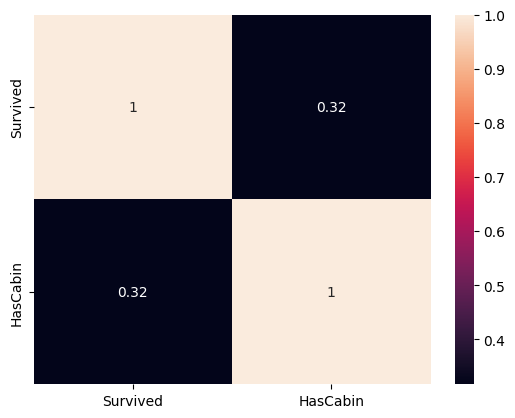

In [32]:
# Before dropping Cabin column, lets check whether Cabin was recorded or not is by itself a good parameter
train["HasCabin"] = train["Cabin"].notnull().astype(int)
test["HasCabin"] = test["Cabin"].notnull().astype(int)

g = sns.heatmap(train[["Survived","HasCabin"]].corr(),annot=True)
# A 0.32 correlation seems pretty good indicator !

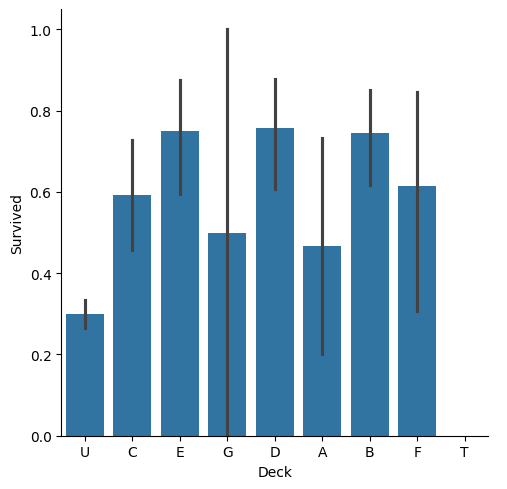

In [33]:
# Lets experiment further within examples with observed Cabin
train['Deck'] = train['Cabin'].fillna('U').apply(lambda x:str(x)[0])
test['Deck'] = test['Cabin'].fillna('U').apply(lambda x:str(x)[0])

sns.catplot(data=train,x="Deck",y="Survived",kind="bar")

In [34]:
train_deck_dummies = pd.get_dummies(train["Deck"],prefix="Deck",dtype=int)
test_deck_dummies = pd.get_dummies(test["Deck"],prefix="Deck",dtype=int)

train = pd.concat([train,train_deck_dummies],axis=1)
test = pd.concat([test,test_deck_dummies],axis=1)

train = train.drop(columns=["Deck"])
test = test.drop(columns=["Deck"])

In [35]:
train = train.drop(columns=["HasCabin","Cabin"])
test = test.drop(columns=["HasCabin","Cabin"])

In [36]:
train = train.drop(columns=["Deck_T"])

In [37]:
# Impact of age will probably be greatly enhanced from name extracted titles
# So first lets shift to title extraction from name

In [38]:
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer', 'Major': 'Officer',
    'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss', 'Lady': 'Royalty', 
    'Sir': 'Royalty', 'Capt': 'Officer', 'Countess': 'Royalty', 
    'Jonkheer': 'Royalty', 'Don': 'Royalty', 'Dona': 'Royalty' 
}

for df in [train,test]:
    df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.',expand=False)
    df['Title'] = df['Title'].map(title_mapping).fillna('Other')

train = train.drop(columns=['Name'])
test = test.drop(columns=['Name'])

In [39]:
# Ordinal Encoding for now to impute Age using Iterative Imputer
title_ordinal_map = {
    'Mr': 1,
    'Miss': 2,
    'Mrs': 3,
    'Master': 4,
    'Officer': 5,
    'Royalty': 6,
    'Other': 0
}

train['Title_encoded'] = train['Title'].map(title_ordinal_map)
test['Title_encoded'] = test['Title'].map(title_ordinal_map)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

impute_cols = ['Pclass','Sex','Title_encoded','Fare','Age']

mice_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42
)

train[impute_cols] = mice_imputer.fit_transform(train[impute_cols])
test[impute_cols] = mice_imputer.transform(test[impute_cols])

In [40]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'Ticket', 'Fare',
       'Family_Solo', 'Family_Small', 'Family_Large', 'Emb_C', 'Emb_Q',
       'Emb_S', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F',
       'Deck_G', 'Deck_U', 'Title', 'Title_encoded'],
      dtype='object')

In [41]:
train = train.drop(columns=['Title_encoded'])
test = test.drop(columns=['Title_encoded'])

train_title_dummies = pd.get_dummies(train["Title"],prefix="Title",dtype=int)
test_title_dummies = pd.get_dummies(test["Title"],prefix="Title",dtype=int)

train = pd.concat([train,train_title_dummies],axis=1)
test = pd.concat([test,test_title_dummies],axis=1)

train = train.drop(columns=["Title"])
test = test.drop(columns=["Title"])

In [42]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'Ticket', 'Fare',
       'Family_Solo', 'Family_Small', 'Family_Large', 'Emb_C', 'Emb_Q',
       'Emb_S', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F',
       'Deck_G', 'Deck_U', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Officer', 'Title_Royalty'],
      dtype='object')

In [43]:
train["Ticket"].head()

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: object

In [44]:
train = train.drop(columns=["Ticket","PassengerId"])
test = test.drop(columns=["Ticket","PassengerId"])

In [45]:
y_train = train["Survived"]
X_train = train.drop(columns=["Survived"])

In [46]:
print(all(X_train.columns==test.columns))

True


**Model Architecture**

In [47]:
import warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,VotingClassifier,StackingClassifier
from xgboost import XGBClassifier

SEED = 42
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)

In [48]:
# 1. Tune Logistic Regression
def objective_lr(trial):
    c_val = trial.suggest_float('C', 1e-3, 10.0, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=c_val, solver=solver, max_iter=1000, random_state=SEED))
    ])
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy').mean()

# 2. Tune Random Forest
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': SEED,
        'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()

# 3. Tune XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'random_state': SEED,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()

In [49]:
print("--- Starting Hyperparameter Tuning ---")

# Tune Logistic Regression
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=30)
best_lr_params = study_lr.best_params
print(f"Best LR Accuracy: {study_lr.best_value:.4f}")

# Tune Random Forest
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=40)
best_rf_params = study_rf.best_params
print(f"Best RF Accuracy: {study_rf.best_value:.4f}")

# Tune XGBoost
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=40)
best_xgb_params = study_xgb.best_params
print(f"Best XGB Accuracy: {study_xgb.best_value:.4f}")


--- Starting Hyperparameter Tuning ---
Best LR Accuracy: 0.8283
Best RF Accuracy: 0.8406
Best XGB Accuracy: 0.8507


In [50]:
# Instantiate tuned base estimators
best_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(**best_lr_params, max_iter=1000, random_state=SEED))
])

best_rf = RandomForestClassifier(**best_rf_params, random_state=SEED, n_jobs=-1)

best_xgb = XGBClassifier(**best_xgb_params, random_state=SEED, eval_metric='logloss', n_jobs=-1)

base_models = [
    ('lr', best_lr),
    ('rf', best_rf),
    ('xgb', best_xgb)
]

# --- Ensemble 1: Soft Voting Classifier ---
voting_ens = VotingClassifier(estimators=base_models, voting='soft')
voting_score = cross_val_score(voting_ens, X_train, y_train, cv=cv, scoring='accuracy').mean()

# --- Ensemble 2: Stacking Classifier (with Logistic Regression Meta-Learner) ---
stacking_ens = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(C=0.1, random_state=SEED),
    cv=cv,
    n_jobs=-1
)
stacking_score = cross_val_score(stacking_ens, X_train, y_train, cv=cv, scoring='accuracy').mean()

print("\n--- Ensemble Results ---")
print(f"Soft Voting CV Accuracy: {voting_score:.4f}")
print(f"Stacking CV Accuracy:    {stacking_score:.4f}")



--- Ensemble Results ---
Soft Voting CV Accuracy: 0.8406
Stacking CV Accuracy:    0.8395


In [51]:
# Choose the winning model (e.g., Stacking)
final_model = stacking_ens if stacking_score >= voting_score else voting_ens

# Fit on full training data
final_model.fit(X_train, y_train)

# Generate test predictions
test_preds = final_model.predict(test)

In [52]:
submission = pd.DataFrame({'PassengerId': test_passenger_ids, 'Survived': test_preds})
submission.to_csv('submission_ensemble.csv', index=False)